# 04 — Treino e Avaliação de Modelos

**Objetivo:** Treinar e avaliar 3 modelos temporais para classificação de emoções:
1. **FlatMLP** — baseline sem modelagem temporal explícita
2. **TemporalCNN1D** — CNN 1D ao longo do eixo temporal
3. **EmoTransformer** — Transformer pequeno com CLS token

**Métricas:** accuracy, macro_f1, balanced_accuracy, precision/recall/f1 por classe,
confusion matrix, bootstrap CI para macro_f1, tempos de treino.

**Hiperparâmetros CPU-first:**
- batch_size = 16
- epochs = 30
- Transformer: d_model=64, 2 layers, 4 heads
- seed = 42

**Outputs:**
- `runs/poc_v1/metrics/metrics.csv`
- `runs/poc_v1/checkpoints/best_transformer.pt`
- `reports/tables/results_table.csv`
- `reports/figures/confusion_matrix_*.png`
- `reports/figures/training_curves.png`
- `reports/figures/f1_per_class.png`

In [1]:
import sys, os, json, time

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import f1_score

from src.models import FlatMLP, TemporalCNN1D, EmoTransformer, count_parameters
from src.metrics_utils import fix_seed, compute_all_metrics, bootstrap_metric, TrainTimer
from src.ravdess_utils import EMOTION_MAP, EMOTION_LABELS

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(f"PyTorch: {torch.__version__}")
print(f"Device: cpu")
print(f"Raiz: {ROOT}")

PyTorch: 2.8.0+cpu
Device: cpu
Raiz: c:\source\vitmodel\vit-emot-poc


## 4.1 Configuração

In [2]:
# ── Hiperparâmetros ──────────────────────────────────────────────────────────
SEED = 42
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
N_CLASSES = 8

# Transformer-specific
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 2
DIM_FF = 128
DROPOUT = 0.1

# Paths
DATA_DIR = os.path.join(ROOT, 'data', 'ravdess_landmarks_kaggle', '01_processed_T100')
SPLIT_DIR = os.path.join(ROOT, 'data', 'ravdess_landmarks_kaggle', '02_splits')
METRICS_DIR = os.path.join(ROOT, 'runs', 'poc_v1', 'metrics')
CKPT_DIR = os.path.join(ROOT, 'runs', 'poc_v1', 'checkpoints')
TABLES_DIR = os.path.join(ROOT, 'reports', 'tables')
FIGS_DIR = os.path.join(ROOT, 'reports', 'figures')

for d in [METRICS_DIR, CKPT_DIR, TABLES_DIR, FIGS_DIR]:
    os.makedirs(d, exist_ok=True)

fix_seed(SEED)
print("Seed fixada:", SEED)

Seed fixada: 42


## 4.2 Carregar Dados e Split

In [3]:
# Carregar dataset
data = np.load(os.path.join(DATA_DIR, 'dataset_T100.npz'), allow_pickle=True)
X_all = data['X']  # (N, T, D)
y_all = data['y']  # (N,)

# Carregar split
with open(os.path.join(SPLIT_DIR, 'split_actor_holdout.json'), 'r') as f:
    split = json.load(f)

train_idx = split['train_indices']
test_idx = split['test_indices']

X_train = X_all[train_idx]
y_train = y_all[train_idx]
X_test = X_all[test_idx]
y_test = y_all[test_idx]

T = X_train.shape[1]  # 100
D = X_train.shape[2]  # número de features

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"T={T}, D={D}, N_CLASSES={N_CLASSES}")

X_train: (2244, 100, 712), y_train: (2244,)
X_test:  (208, 100, 712),  y_test:  (208,)
T=100, D=712, N_CLASSES=8


In [4]:
# Normalização z-score (fit no train, aplica no test)
# Reshape para (N*T, D) para calcular stats
train_flat = X_train.reshape(-1, D)
mu = train_flat.mean(axis=0)
sigma = train_flat.std(axis=0)
sigma[sigma == 0] = 1.0  # evitar divisão por zero

X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

print(f"Após z-score:")
print(f"  Train — mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")
print(f"  Test  — mean: {X_test.mean():.4f}, std: {X_test.std():.4f}")

Após z-score:
  Train — mean: -0.0002, std: 1.0000
  Test  — mean: 0.0549, std: 0.9236


In [5]:
# Criar DataLoaders
train_ds = TensorDataset(
    torch.FloatTensor(X_train),
    torch.LongTensor(y_train),
)
test_ds = TensorDataset(
    torch.FloatTensor(X_test),
    torch.LongTensor(y_test),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 141
Test batches:  13


## 4.3 Funções de Treino e Avaliação

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    criterion = nn.CrossEntropyLoss()

    for X_batch, y_batch in loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(all_labels)

    return avg_loss, all_preds, all_labels


def train_model(model, model_name, train_loader, test_loader,
                epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    """
    Treina um modelo e retorna histórico + predições finais.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_test_f1 = -1
    best_state = None

    print(f"\n{'='*60}")
    print(f"Treinando: {model_name}")
    print(f"Parâmetros: {count_parameters(model):,}")
    print(f"{'='*60}")

    timer = TrainTimer()
    with timer:
        for epoch in range(epochs):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
            test_loss, test_preds, test_labels = evaluate(model, test_loader)
            test_acc = (test_preds == test_labels).mean()
            test_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['test_loss'].append(test_loss)
            history['test_acc'].append(test_acc)

            scheduler.step()

            # Salvar melhor modelo
            if test_f1 > best_test_f1:
                best_test_f1 = test_f1
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                best_epoch = epoch + 1

            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1:3d}/{epochs} | "
                      f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
                      f"Test Loss: {test_loss:.4f} Acc: {test_acc:.3f} F1: {test_f1:.3f}")

    print(f"\nMelhor epoch: {best_epoch} (F1={best_test_f1:.4f})")
    print(f"Tempo de treino: {timer.elapsed_str}")

    # Restaurar melhor modelo
    model.load_state_dict(best_state)

    # Avaliação final
    _, final_preds, final_labels = evaluate(model, test_loader)

    return {
        'model': model,
        'model_name': model_name,
        'history': history,
        'best_epoch': best_epoch,
        'train_time': timer.elapsed,
        'train_time_str': timer.elapsed_str,
        'n_params': count_parameters(model),
        'final_preds': final_preds,
        'final_labels': final_labels,
    }

## 4.4 Treinar os 3 Modelos

In [7]:
# ── Modelo 1: FlatMLP ─────────────────────────────────────────────────────────
fix_seed(SEED)
mlp_model = FlatMLP(T=T, D=D, n_classes=N_CLASSES, hidden=256)
mlp_result = train_model(mlp_model, 'FlatMLP', train_loader, test_loader)


Treinando: FlatMLP
Parâmetros: 18,261,384
  Epoch   1/30 | Train Loss: 7.5251 Acc: 0.262 | Test Loss: 1.8640 Acc: 0.245 F1: 0.205
  Epoch   5/30 | Train Loss: 1.5721 Acc: 0.417 | Test Loss: 1.3831 Acc: 0.466 F1: 0.411
  Epoch  10/30 | Train Loss: 1.1270 Acc: 0.584 | Test Loss: 1.2902 Acc: 0.543 F1: 0.516
  Epoch  15/30 | Train Loss: 0.8647 Acc: 0.679 | Test Loss: 1.0123 Acc: 0.639 F1: 0.586
  Epoch  20/30 | Train Loss: 0.5700 Acc: 0.792 | Test Loss: 0.9058 Acc: 0.697 F1: 0.674
  Epoch  25/30 | Train Loss: 0.3213 Acc: 0.873 | Test Loss: 0.8129 Acc: 0.740 F1: 0.727
  Epoch  30/30 | Train Loss: 0.2851 Acc: 0.889 | Test Loss: 0.8942 Acc: 0.750 F1: 0.737

Melhor epoch: 26 (F1=0.7426)
Tempo de treino: 8m 1.2s


In [8]:
# ── Modelo 2: CNN1D ───────────────────────────────────────────────────────────
fix_seed(SEED)
cnn_model = TemporalCNN1D(T=T, D=D, n_classes=N_CLASSES, n_filters=64, kernel_size=5)
cnn_result = train_model(cnn_model, 'TemporalCNN1D', train_loader, test_loader)


Treinando: TemporalCNN1D
Parâmetros: 303,304
  Epoch   1/30 | Train Loss: 1.5399 Acc: 0.413 | Test Loss: 1.3604 Acc: 0.514 F1: 0.444
  Epoch   5/30 | Train Loss: 0.6520 Acc: 0.772 | Test Loss: 1.0148 Acc: 0.620 F1: 0.622
  Epoch  10/30 | Train Loss: 0.4407 Acc: 0.843 | Test Loss: 0.9507 Acc: 0.692 F1: 0.674
  Epoch  15/30 | Train Loss: 0.2787 Acc: 0.898 | Test Loss: 1.0638 Acc: 0.688 F1: 0.671
  Epoch  20/30 | Train Loss: 0.1987 Acc: 0.929 | Test Loss: 1.1415 Acc: 0.683 F1: 0.671
  Epoch  25/30 | Train Loss: 0.1269 Acc: 0.956 | Test Loss: 1.1544 Acc: 0.678 F1: 0.660
  Epoch  30/30 | Train Loss: 0.1111 Acc: 0.967 | Test Loss: 1.0970 Acc: 0.692 F1: 0.670

Melhor epoch: 26 (F1=0.7056)
Tempo de treino: 3m 0.0s


In [9]:
# ── Modelo 3: EmoTransformer ──────────────────────────────────────────────────
fix_seed(SEED)
transformer_model = EmoTransformer(
    D=D, n_classes=N_CLASSES,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
    dim_ff=DIM_FF, dropout=DROPOUT,
)
transformer_result = train_model(transformer_model, 'EmoTransformer', train_loader, test_loader)


Treinando: EmoTransformer
Parâmetros: 113,288
  Epoch   1/30 | Train Loss: 1.4644 Acc: 0.461 | Test Loss: 1.0059 Acc: 0.596 F1: 0.572
  Epoch   5/30 | Train Loss: 0.4755 Acc: 0.828 | Test Loss: 0.6654 Acc: 0.769 F1: 0.763
  Epoch  10/30 | Train Loss: 0.2536 Acc: 0.911 | Test Loss: 0.8322 Acc: 0.750 F1: 0.750
  Epoch  15/30 | Train Loss: 0.1081 Acc: 0.965 | Test Loss: 1.0113 Acc: 0.740 F1: 0.726
  Epoch  20/30 | Train Loss: 0.0424 Acc: 0.988 | Test Loss: 1.1780 Acc: 0.712 F1: 0.707
  Epoch  25/30 | Train Loss: 0.0176 Acc: 0.997 | Test Loss: 1.1985 Acc: 0.721 F1: 0.717
  Epoch  30/30 | Train Loss: 0.0129 Acc: 0.999 | Test Loss: 1.1807 Acc: 0.721 F1: 0.715

Melhor epoch: 5 (F1=0.7632)
Tempo de treino: 7m 54.2s


In [10]:
# Salvar checkpoint do Transformer
ckpt_path = os.path.join(CKPT_DIR, 'best_transformer.pt')
torch.save({
    'model_state_dict': transformer_model.state_dict(),
    'config': {
        'D': D, 'n_classes': N_CLASSES,
        'd_model': D_MODEL, 'n_heads': N_HEADS, 'n_layers': N_LAYERS,
        'dim_ff': DIM_FF, 'dropout': DROPOUT,
    },
    'seed': SEED,
    'best_epoch': transformer_result['best_epoch'],
    'normalization': {'mu': mu.tolist(), 'sigma': sigma.tolist()},
}, ckpt_path)
print(f"Checkpoint salvo: {ckpt_path}")

Checkpoint salvo: c:\source\vitmodel\vit-emot-poc\runs\poc_v1\checkpoints\best_transformer.pt


## 4.5 Métricas Detalhadas

In [11]:
# Determinar class_names com base nas classes que realmente existem no dataset
unique_classes = sorted(np.unique(y_all))
class_names = [EMOTION_MAP.get(c + 1, f"emo_{c}") for c in unique_classes]
print(f"Classes: {class_names}")

all_results = [mlp_result, cnn_result, transformer_result]
metrics_rows = []

for res in all_results:
    name = res['model_name']
    preds = res['final_preds']
    labels = res['final_labels']

    m = compute_all_metrics(labels, preds, class_names=class_names)
    res['metrics'] = m  # guardar para uso posterior

    # Bootstrap para macro_f1
    boot = bootstrap_metric(
        labels, preds,
        metric_fn=lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
        n_bootstrap=200, seed=SEED,
    )
    res['bootstrap_f1'] = boot

    print(f"\n{'='*60}")
    print(f"Resultados: {name}")
    print(f"{'='*60}")
    print(f"  Accuracy:          {m['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {m['balanced_accuracy']:.4f}")
    print(f"  Macro F1:          {m['macro_f1']:.4f}")
    print(f"  F1 Bootstrap 95%CI: [{boot['ci_lower']:.4f}, {boot['ci_upper']:.4f}]")
    print(f"  Parâmetros:        {res['n_params']:,}")
    print(f"  Tempo de treino:   {res['train_time_str']}")
    print(f"  Melhor época:      {res['best_epoch']}")

    # Montar row para tabela
    row = {
        'model': name,
        'accuracy': round(m['accuracy'], 4),
        'balanced_accuracy': round(m['balanced_accuracy'], 4),
        'macro_f1': round(m['macro_f1'], 4),
        'f1_ci_lower': round(boot['ci_lower'], 4),
        'f1_ci_upper': round(boot['ci_upper'], 4),
        'n_params': res['n_params'],
        'train_time_s': round(res['train_time'], 1),
        'best_epoch': res['best_epoch'],
        'seed': SEED,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'n_train': len(y_train),
        'n_test': len(y_test),
    }

    # F1 por classe
    report = m['classification_report']
    for cn in class_names:
        if cn in report:
            row[f'f1_{cn}'] = round(report[cn]['f1-score'], 4)
            row[f'precision_{cn}'] = round(report[cn]['precision'], 4)
            row[f'recall_{cn}'] = round(report[cn]['recall'], 4)

    metrics_rows.append(row)

Classes: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

Resultados: FlatMLP
  Accuracy:          0.7548
  Balanced Accuracy: 0.7617
  Macro F1:          0.7426
  F1 Bootstrap 95%CI: [0.6796, 0.7964]
  Parâmetros:        18,261,384
  Tempo de treino:   8m 1.2s
  Melhor época:      26

Resultados: TemporalCNN1D
  Accuracy:          0.7260
  Balanced Accuracy: 0.7109
  Macro F1:          0.7056
  F1 Bootstrap 95%CI: [0.6552, 0.7697]
  Parâmetros:        303,304
  Tempo de treino:   3m 0.0s
  Melhor época:      26

Resultados: EmoTransformer
  Accuracy:          0.7692
  Balanced Accuracy: 0.7734
  Macro F1:          0.7632
  F1 Bootstrap 95%CI: [0.6969, 0.8170]
  Parâmetros:        113,288
  Tempo de treino:   7m 54.2s
  Melhor época:      5


In [12]:
# Classification Report completo para cada modelo
from sklearn.metrics import classification_report as cr_text

for res in all_results:
    print(f"\n{'='*70}")
    print(f"Classification Report: {res['model_name']}")
    print(f"{'='*70}")
    print(cr_text(res['final_labels'], res['final_preds'],
                  target_names=class_names, zero_division=0))


Classification Report: FlatMLP
              precision    recall  f1-score   support

     neutral       0.33      0.94      0.49        16
        calm       0.90      0.59      0.72        32
       happy       1.00      0.97      0.98        32
         sad       1.00      0.59      0.75        32
       angry       0.81      0.81      0.81        32
     fearful       0.83      0.75      0.79        32
     disgust       0.76      1.00      0.86        16
   surprised       0.70      0.44      0.54        16

    accuracy                           0.75       208
   macro avg       0.79      0.76      0.74       208
weighted avg       0.84      0.75      0.77       208


Classification Report: TemporalCNN1D
              precision    recall  f1-score   support

     neutral       0.30      0.62      0.41        16
        calm       0.95      0.66      0.78        32
       happy       0.97      0.94      0.95        32
         sad       0.90      0.56      0.69        32
       a

## 4.6 Salvar Métricas

In [13]:
# Salvar métricas
metrics_df = pd.DataFrame(metrics_rows)

metrics_path = os.path.join(METRICS_DIR, 'metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"Métricas salvas: {metrics_path}")

results_path = os.path.join(TABLES_DIR, 'results_table.csv')
metrics_df.to_csv(results_path, index=False)
print(f"Tabela de resultados: {results_path}")

# Tabela resumo (para o artigo)
summary_cols = ['model', 'accuracy', 'balanced_accuracy', 'macro_f1',
                'f1_ci_lower', 'f1_ci_upper', 'n_params', 'train_time_s']
print("\n--- Tabela Resumo (para artigo) ---")
metrics_df[summary_cols]

Métricas salvas: c:\source\vitmodel\vit-emot-poc\runs\poc_v1\metrics\metrics.csv
Tabela de resultados: c:\source\vitmodel\vit-emot-poc\reports\tables\results_table.csv

--- Tabela Resumo (para artigo) ---


,model,accuracy,balanced_accuracy,macro_f1,f1_ci_lower,f1_ci_upper,n_params,train_time_s
0,FlatMLP,0.7548,0.7617,0.7426,0.6796,0.7964,18261384,481.2
1,TemporalCNN1D,0.7260,0.7109,0.7056,0.6552,0.7697,303304,180.0
2,EmoTransformer,0.7692,0.7734,0.7632,0.6969,0.8170,113288,474.2


## 4.7 Visualizações

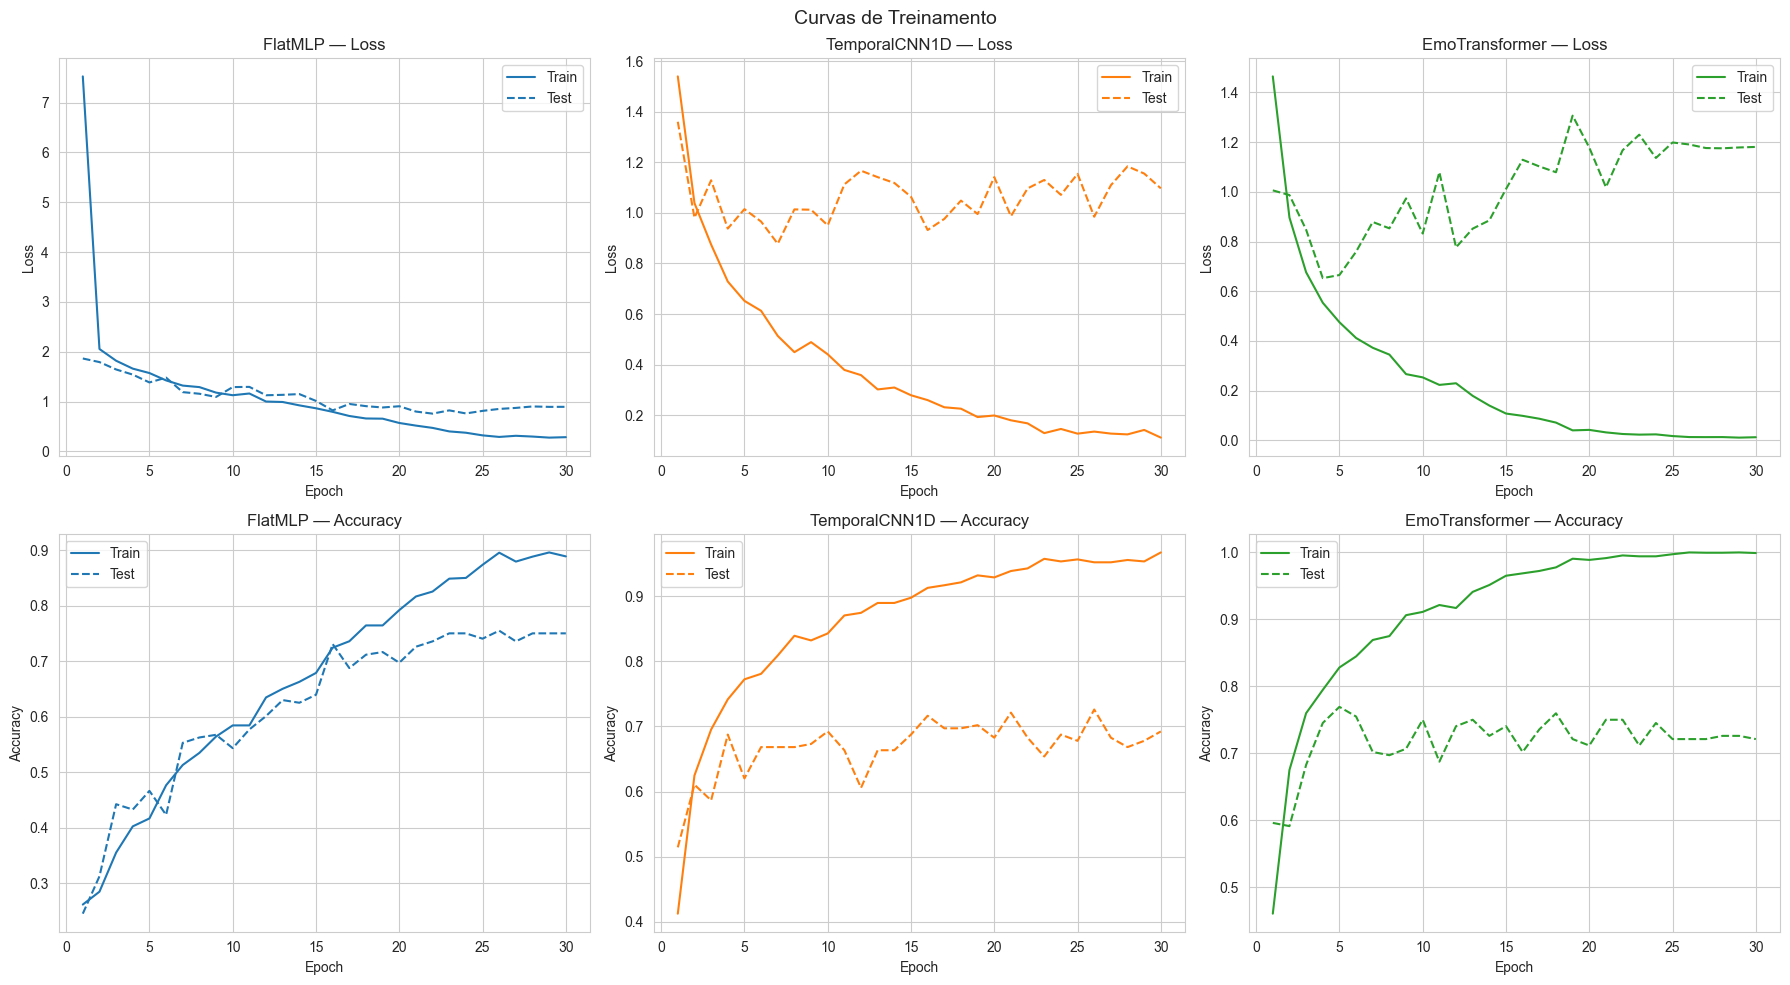

Salvo: c:\source\vitmodel\vit-emot-poc\reports\figures\training_curves.png


In [14]:
# ── Curvas de Loss e Accuracy ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, res in enumerate(all_results):
    h = res['history']
    epochs_range = range(1, len(h['train_loss']) + 1)

    # Loss
    axes[0, i].plot(epochs_range, h['train_loss'], label='Train', color=colors[i])
    axes[0, i].plot(epochs_range, h['test_loss'], label='Test', linestyle='--', color=colors[i])
    axes[0, i].set_title(f"{res['model_name']} — Loss")
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].legend()

    # Accuracy
    axes[1, i].plot(epochs_range, h['train_acc'], label='Train', color=colors[i])
    axes[1, i].plot(epochs_range, h['test_acc'], label='Test', linestyle='--', color=colors[i])
    axes[1, i].set_title(f"{res['model_name']} — Accuracy")
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Accuracy')
    axes[1, i].legend()

plt.suptitle('Curvas de Treinamento', fontsize=14)
plt.tight_layout()
fig_path = os.path.join(FIGS_DIR, 'training_curves.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvo: {fig_path}")

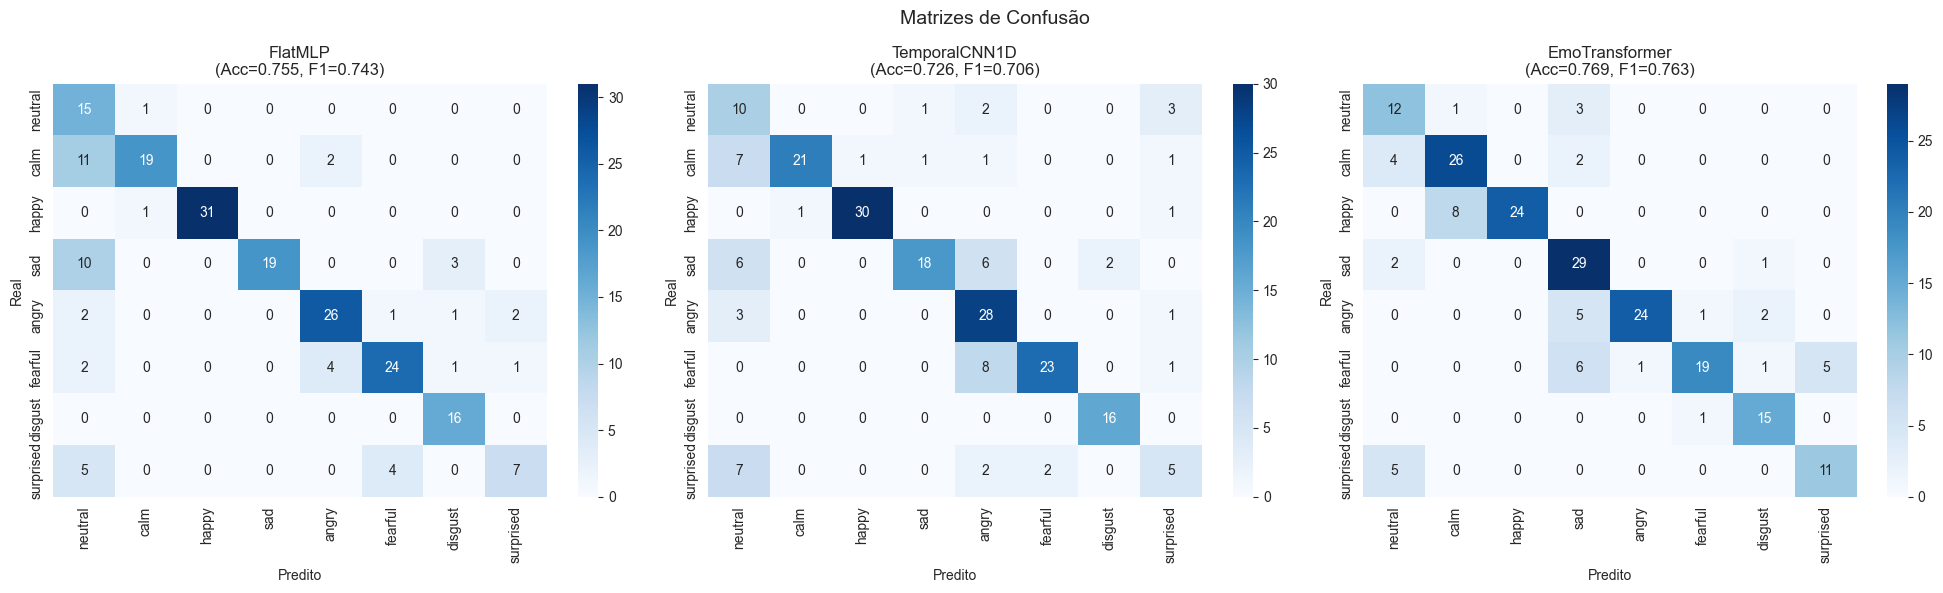

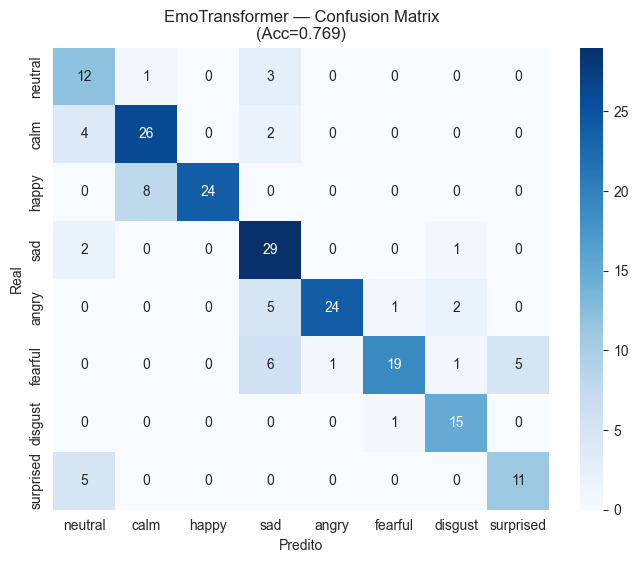

Matrizes de confusão salvas em reports/figures/


In [15]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, res in enumerate(all_results):
    cm = res['metrics']['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[i])
    axes[i].set_title(f"{res['model_name']}\n(Acc={res['metrics']['accuracy']:.3f}, F1={res['metrics']['macro_f1']:.3f})")
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrizes de Confusão', fontsize=14)
plt.tight_layout()

# Salvar individual do Transformer e conjunto
fig.savefig(os.path.join(FIGS_DIR, 'confusion_matrix_all.png'), dpi=150, bbox_inches='tight')
plt.show()

# Salvar individual do Transformer
fig2, ax2 = plt.subplots(figsize=(8, 6))
cm_t = transformer_result['metrics']['confusion_matrix']
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title(f"EmoTransformer — Confusion Matrix\n(Acc={transformer_result['metrics']['accuracy']:.3f})")
ax2.set_xlabel('Predito')
ax2.set_ylabel('Real')
fig2.savefig(os.path.join(FIGS_DIR, 'confusion_matrix_transformer.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Matrizes de confusão salvas em reports/figures/")

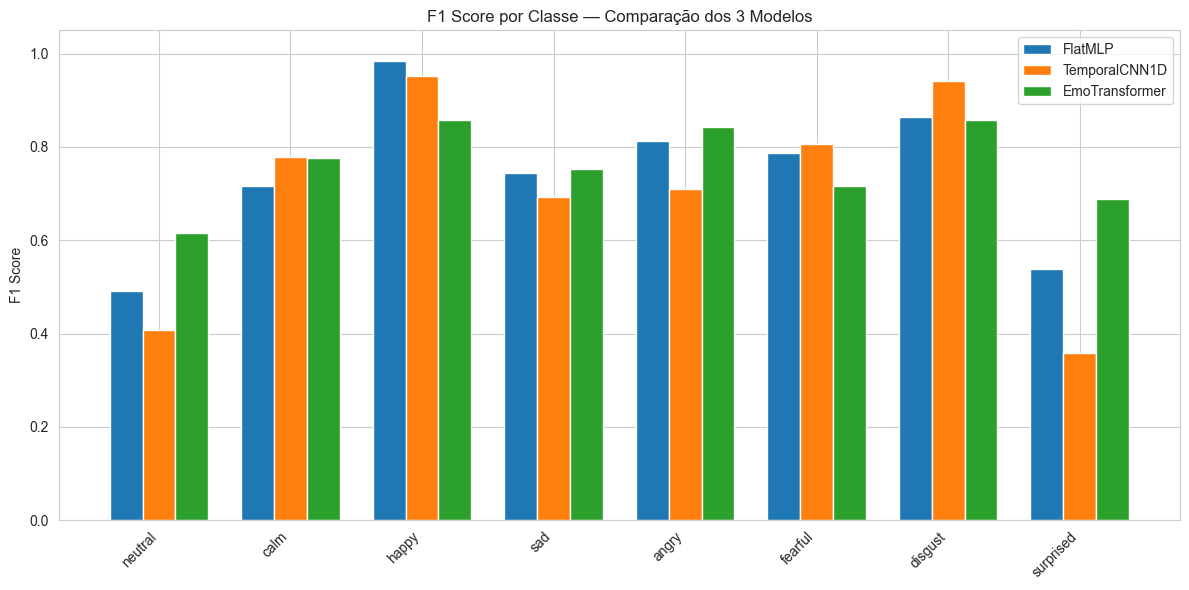

Salvo: reports/figures/f1_per_class.png


In [16]:
# ── F1 por classe (barplot comparativo) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(class_names))
width = 0.25

for i, res in enumerate(all_results):
    report = res['metrics']['classification_report']
    f1_vals = [report.get(cn, {}).get('f1-score', 0) for cn in class_names]
    ax.bar(x_pos + i * width, f1_vals, width, label=res['model_name'], color=colors[i])

ax.set_xticks(x_pos + width)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score por Classe — Comparação dos 3 Modelos')
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'f1_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvo: reports/figures/f1_per_class.png")

In [17]:
# ── Resumo final ──────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("RESUMO FINAL — RESULTADOS DO POC")
print("=" * 70)
print(f"Dataset: {len(y_train)} train + {len(y_test)} test = {len(y_all)} total")
print(f"Classes: {N_CLASSES} ({', '.join(class_names)})")
print(f"Features: D={D}, T={T}")
print(f"Seed: {SEED}, Epochs: {EPOCHS}, Batch: {BATCH_SIZE}")
print()
for res in all_results:
    m = res['metrics']
    b = res['bootstrap_f1']
    print(f"  {res['model_name']:20s} | Acc={m['accuracy']:.3f} | BalAcc={m['balanced_accuracy']:.3f} | "
          f"F1={m['macro_f1']:.3f} [{b['ci_lower']:.3f}-{b['ci_upper']:.3f}] | "
          f"Params={res['n_params']:,} | Time={res['train_time_str']}")
print("=" * 70)
print("\nNotebook 04 concluído com sucesso!")


RESUMO FINAL — RESULTADOS DO POC
Dataset: 2244 train + 208 test = 2452 total
Classes: 8 (neutral, calm, happy, sad, angry, fearful, disgust, surprised)
Features: D=712, T=100
Seed: 42, Epochs: 30, Batch: 16

  FlatMLP              | Acc=0.755 | BalAcc=0.762 | F1=0.743 [0.680-0.796] | Params=18,261,384 | Time=8m 1.2s
  TemporalCNN1D        | Acc=0.726 | BalAcc=0.711 | F1=0.706 [0.655-0.770] | Params=303,304 | Time=3m 0.0s
  EmoTransformer       | Acc=0.769 | BalAcc=0.773 | F1=0.763 [0.697-0.817] | Params=113,288 | Time=7m 54.2s

Notebook 04 concluído com sucesso!
